# 基于 Embedding  的 IMDB 情感分类

本 Notebook 演示如何使用 PyTorch 构建一个基于词嵌入 + 全局平均池化的文本分类模型，完成 IMDB 电影评论情感分类任务。

In [176]:
import matplotlib as mpl           # Matplotlib 主模块，用于绘图配置
import matplotlib.pyplot as plt     # pyplot：提供类似 MATLAB 的绘图接口
%matplotlib inline                 
 # Jupyter 魔法命令：将图表直接渲染在 Notebook 中
import numpy as np                  # NumPy：高性能数值计算库
import sklearn                      # Scikit-learn：机器学习工具库（用于 accuracy_score 等）
import pandas as pd                 # Pandas：数据处理与分析库
import os                           # os 模块：操作系统接口（文件/目录操作）
import sys                          # sys 模块：访问 Python 解释器相关信息
import time                         # time 模块：时间相关函数
from tqdm import tqdm          # tqdm：进度条工具，auto 模式自动适配终端/Jupyter
import torch                        # PyTorch 核心模块
import torch.nn as nn               # torch.nn：神经网络模块（层、损失函数等）
import torch.nn.functional as F     # torch.nn.functional：无参数的函数式 API（激活函数、损失等）

# 打印 Python 版本信息
print(sys.version_info)
# 打印各依赖库的版本，便于复现实验环境
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 优先使用 GPU（cuda:0），若不可用则退回 CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 打印当前使用的设备

seed = 42  # 随机种子，用于保证实验可复现性


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 一、加载 IMDB 数据集

本节通过 HuggingFace `datasets` 库加载 [stanfordnlp/imdb](https://huggingface.co/datasets/stanfordnlp/imdb) 数据集。该数据集包含 **50 000** 条英文电影评论，已划分为训练集 25 000 条、测试集 25 000 条；每条样本包含原始文本 `text` 与情感标签 `label`（0 = 负面，1 = 正面）。与 Keras 预处理后版本不同，此处保留**原始字符串**，便于后续自定义分词与词典构建。

### 1.1 从 HuggingFace 下载并缓存数据集

使用 `load_dataset` 接口自动下载数据到本地 `cache_dir`，避免重复联网。返回值为 `DatasetDict` 类型，可通过键名 `'train'`、`'test'` 访问各子集。

In [177]:
from datasets import load_dataset  # HuggingFace datasets 库：提供 load_dataset 统一数据加载接口

cache_dir = 'data/imdb'  # str：本地缓存目录路径，下载后的 Arrow 文件将保存在此

if not os.path.exists(cache_dir):  # os.path.exists(path) -> bool：判断目录是否已存在
    os.makedirs(cache_dir)  # os.makedirs(path)：递归创建目录（含父目录），已存在时不报错

# load_dataset(name, cache_dir) -> DatasetDict
#   name: 数据集标识符，'stanfordnlp/imdb' 为 Stanford NLP 发布的 IMDB 影评数据集
#   cache_dir: 指定缓存位置，第二次运行将直接读取本地文件，无需重新下载
dataset = load_dataset('stanfordnlp/imdb', cache_dir=cache_dir)

print(type(dataset))  # 预期输出 <class 'datasets.dataset_dict.DatasetDict'>，类似字典，键为 split 名
print(type(dataset['train']['text']))  # 预期输出 Column 类型，存储该列所有文本，支持索引访问

<class 'datasets.dataset_dict.DatasetDict'>
<class 'datasets.arrow_dataset.Column'>


### 1.2 提取训练集与测试集的文本和标签

将 `DatasetDict` 中各 split 的 `text`、`label` 列转为 NumPy 一维数组，便于后续向量化处理与批训练。`label` 为整数 0（负面）或 1（正面）。

In [178]:
# np.array(iterable) -> ndarray：将 Column / 列表转为 NumPy 数组，dtype 由元素类型自动推断
train_texts = np.array(dataset['train']['text'])    # shape=(25000,)，元素为 str，训练集评论原文
train_labels = np.array(dataset['train']['label'])  # shape=(25000,)，元素为 int64，取值 0 或 1
test_texts = np.array(dataset['test']['text'])      # shape=(25000,)，测试集评论原文
test_labels = np.array(dataset['test']['label'])    # shape=(25000,)，测试集情感标签

## 二、构造 word2idx 和 idx2word

在自然语言处理中，模型只能处理数值输入，因此需要将单词映射为整数索引。本节基于**训练集**统计词频、构建有限大小的词典，并预留特殊符号：`<PAD>`（填充）、`<OOV>`（未登录词）、`<BOS>`（句首）、`<EOS>`（句尾）。测试集中未出现在训练词典里的词将统一映射为 `<OOV>`。

### 2.1 文本清洗与分词

对训练文本做简单规范化：将标点替换为空格、合并连续空白，再按空格切分为词列表。仅在训练集上统计词频，避免测试集信息泄露。

In [179]:
from collections import Counter  # Counter：可哈希元素的可变映射，专门用于词频统计；most_common(n) 按频率降序返回最高频 n 项

import re  # re：正则表达式模块，用于复杂字符串模式匹配与替换

def clean_text(text):
    """
    对单条评论做轻量文本清洗。

    参数:
        text (str): 原始电影评论字符串。

    返回:
        str: 清洗后的文本，首尾无多余空白，词与词之间以单个空格分隔。
    """
    text = text.replace(',', ' ').replace('.', ' ')  # 将逗号、句号替换为空格，弱化标点对分词的影响
    text = re.sub(r'\s+', ' ', text)  # re.sub(pattern, repl, s)：将连续空白（空格/换行/制表符）合并为一个空格
    return text.strip()  # str.strip()：去除首尾空白字符，返回新字符串

# 列表推导式：对 train_texts 中每条评论调用 clean_text，再封装为 NumPy 数组
train_texts = np.array([clean_text(t) for t in train_texts])  # shape 仍为 (25000,)，元素为清洗后的 str

all_words = []  # list[str]：存放训练集全部分词结果，用于后续统计词频
for text in train_texts:  # 遍历每条清洗后的评论
    all_words.extend(text.split())  # str.split()：默认按任意空白切分，返回 list[str]；extend 将词追加到 all_words

word_counts = Counter(all_words)  # Counter(all_words) -> Counter：键为单词，值为出现次数

### 2.2 构建 word2idx 与 idx2word 映射

选取词频最高的若干词填入词典（索引从 4 起），并建立反向映射 `idx2word`，便于将整数索引还原为可读单词。超出词典容量的词在编码阶段将映射为 `<OOV>`（索引 1）。

In [180]:
max_vocab_size = 20000  # int：词典总容量上限（含 4 个特殊符号），Embedding 层 num_embeddings 将与此一致

# dict[str, int]：词 -> 索引；索引 0~3 预留给特殊 token，普通词从 4 开始编号
word2idx = {'<PAD>': 0, '<OOV>': 1, '<BOS>': 2, '<EOS>': 3}

# Counter.most_common(n) -> list[tuple[str, int]]：返回频率最高的 n 个 (词, 次数) 元组
# 排序规则：按词频降序（出现次数多的在前，少的在后），频率相同时按首次出现顺序排列
most_common_words = word_counts.most_common(max_vocab_size - 4)  # 预留 4 个位置给特殊符号；列表首项为最高频词

start = 4  # int：普通词汇索引起始值（0~3 已被特殊符号占用）
for idx, (word, count) in enumerate(most_common_words, start=start):
    # enumerate(iterable, start)：同时产出索引 idx 与元素 (word, count)
    # 因 most_common 为降序，idx=4 对应最高频词，idx 越大对应词频越低
    word2idx[word] = idx  # 将高频词写入正向词典，idx 从 4 递增到 max_vocab_size - 1

print(f"词典大小: {len(word2idx)}")  # len(dict) -> int：当前词典中的条目总数

# 字典推导式：由 word2idx 反转得到 idx2word，键为 int 索引，值为 str 单词
idx2word = {idx: word for word, idx in word2idx.items()}  # dict[int, str]

for i in range(10):  # 打印前 10 个索引对应的词，验证特殊符号与普通词编号是否正确
    print(f"{i}: {idx2word[i]}")  # 预期 0~3 为 <PAD>/<OOV>/<BOS>/<EOS>，4 起为高频实词

词典大小: 20000
0: <PAD>
1: <OOV>
2: <BOS>
3: <EOS>
4: the
5: a
6: and
7: of
8: to
9: is


## 三、分析数据长度分布

统计训练集中各评论的单词数（序列长度），可视化其分布，并确定截断/填充的最大长度 `MAX_LENGTH`。

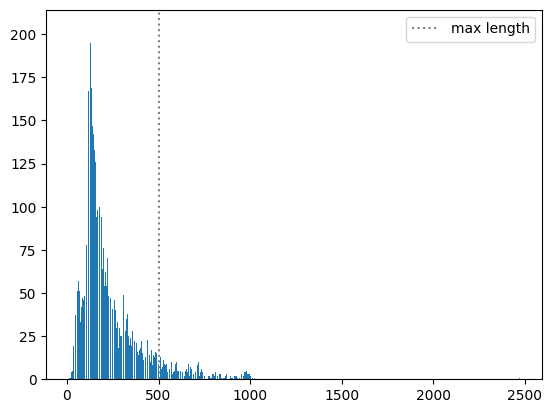

In [181]:
# 选择合适的最大序列长度（max_length）
length_collect = {}  # 用字典存储 {序列长度: 出现次数} 的频率统计

# 遍历训练集中每条评论，统计其长度出现次数
for text in train_texts:
    length = len(text.split())                                       # 获取当前评论的单词数（序列长度）
    length_collect[length] = length_collect.get(length, 0) + 1  # 累计该长度出现次数

# 设置最大序列长度——超过此长度的评论将被截断，短于此长度的将被填充（Padding）
MAX_LENGTH = 500

# 绘制各长度频率的柱状图，横轴为序列长度，纵轴为出现次数
plt.bar(length_collect.keys(), length_collect.values())
# 在 MAX_LENGTH=500 处绘制竖虚线，直观展示截断位置（绝大多数评论长度在 500 以内）
plt.axvline(MAX_LENGTH, label="max length", c="gray", ls=":")
plt.legend()  # 显示图例
plt.show()    # 渲染图表

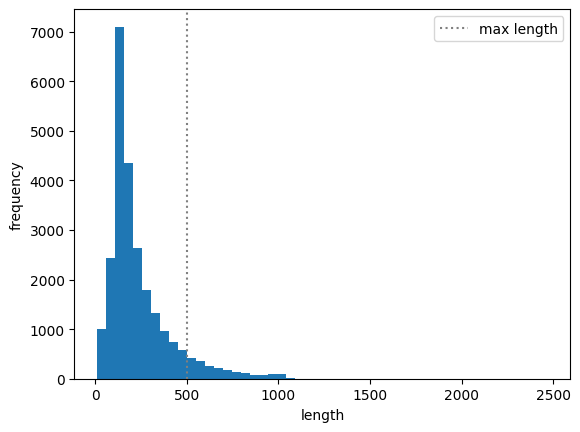

In [182]:
# 用直方图更直观地展示句子长度分布（bins=50 将范围分为 50 个区间）
# 列表推导式：提取每条评论的单词数，生成长度列表
length_list = [len(text.split()) for text in train_texts]  # List[int]，每个元素为对应评论的长度

# 绘制长度分布直方图
plt.hist(length_list, bins=50)       # bins=50：将长度范围均分为 50 个区间
plt.xlabel("length")                 # 横轴：序列长度（单词数）
plt.ylabel("frequency")              # 纵轴：出现频次
plt.axvline(500, label="max length", c="gray", ls=":")  # 在 500 处画竖虚线标注截断点
plt.legend()                         # 显示图例
plt.show()                           # 渲染图表

### 3.1 查看前 10 条样本的长度

In [183]:
# 查看前 10 条训练样本的序列长度
# 返回值：List[int]，例如 [218, 189, 141, ...]
# 可以看到不同评论的长度差异很大，因此需要 Padding 将其统一到相同长度
length_list[0:10]

[292, 214, 96, 121, 325, 123, 114, 303, 486, 224]

In [184]:
# 构造一个用于演示 Tokenizer 功能的原始文本列表（批量输入格式）
# 每个元素都是 List[str]（分词后的单词列表），模拟真实 NLP 管道中的批次数据
raw_text = [
    "hello world".split(),               # 样本 1：["hello", "world"]
    "tokenize text datas with batch".split(),  # 样本 2：5 个单词
    "this is a test".split()             # 样本 3：4 个单词
]
raw_text  # 打印查看批次原始文本结构

[['hello', 'world'],
 ['tokenize', 'text', 'datas', 'with', 'batch'],
 ['this', 'is', 'a', 'test']]

## 四、Tokenizer

封装一个 `Tokenizer` 类，实现 **编码（Encode）** 和 **解码（Decode）** 两大核心功能：
- **Encode**：将原始文本批次转换为填充后的整数 id 张量
- **Decode**：将整数 id 序列还原为可读文本

In [185]:
class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=500,
                 pad_idx=0, bos_idx=2, eos_idx=3, unk_idx=1,
                 truncate_mode='adaptive'):
        """
        初始化 Tokenizer（文本编解码器）
        参数：
            word2idx       (Dict[str,int]): 单词 → id 映射字典
            idx2word       (Dict[int,str]): id → 单词 映射字典
            max_length     (int):           序列最大长度，超出则按 truncate_mode 处理，默认 500
            pad_idx        (int):           填充 token 的 id，默认 0
            bos_idx        (int):           句子起始 token 的 id，默认 2
            eos_idx        (int):           句子结束 token 的 id，默认 3
            unk_idx        (int):           未知词 token 的 id，默认 1
            truncate_mode  (str):           超长序列截断策略，默认 'adaptive'
                - 'adaptive'：自适应步长，在全文上等间隔采样 max_length 个 token
                - 'head'    ：保留句首，丢弃末尾（index[:max_length]）
                - 'tail'    ：保留句尾，丢弃开头（index[-max_length:]）
        """
        self.word2idx       = word2idx        # 单词 → id 字典，用于编码
        self.idx2word       = idx2word        # id → 单词 字典，用于解码
        self.max_length     = max_length      # 序列截断/填充的最大长度
        self.pad_idx        = pad_idx         # 填充符 id
        self.bos_idx        = bos_idx         # 句子起始符 id
        self.eos_idx        = eos_idx         # 句子结束符 id
        self.unk_idx        = unk_idx         # 未知词 id
        valid_modes = ('adaptive', 'head', 'tail')  # 允许的截断策略枚举
        if truncate_mode not in valid_modes:
            raise ValueError(f"truncate_mode 必须是 {valid_modes} 之一，当前为 {truncate_mode!r}")
        self.truncate_mode  = truncate_mode   # str：超长序列截断策略

    def _truncate_to_max_length(self, index, max_length):
        """
        将超长 id 序列压缩到 max_length（仅当 len(index) >= max_length 时调用）
        参数：
            index      (List[int]): 单条样本的 token id 列表
            max_length (int):       目标序列长度
        返回：
            List[int]，长度恒为 max_length
        """
        if self.truncate_mode == 'head':
            return index[:max_length]  # 保留句首 max_length 个 token，丢弃末尾
        if self.truncate_mode == 'tail':
            return index[-max_length:]  # 保留句尾 max_length 个 token，丢弃开头
        # adaptive：步长 step ≈ len(index) / max_length，在 [0, len-1] 上等间隔采样
        positions = np.linspace(0, len(index) - 1, max_length, dtype=int)  # ndarray[int]，形状 (max_length,)
        return [index[i] for i in positions]  # List[int]，兼顾首尾与中间信息

    def encode(self, text_list):
        """
        将文本列表批量编码为整数 id 张量
        参数：
            text_list (List[List[str]]): 每条文本已拆分为单词列表
        返回：
            torch.Tensor，形状 (batch_size, seq_len)，dtype=torch.long
        """
        # 动态确定本批次的序列长度（取最长句，但不超过 max_length）
        max_length = min(self.max_length, max(
            [len(text) for text in text_list]))  

        indices = []
        for text in text_list:
            index = [self.word2idx.get(word, self.unk_idx) for word in text]  # 单词 → id
            if len(index) < max_length:
                index = index + [self.pad_idx] * (max_length - len(index))  # 右填充 PAD
            else:
                index = self._truncate_to_max_length(index, max_length)  # 按 truncate_mode 处理超长序列
            indices.append(index)
        return torch.tensor(indices)  # List[List[int]] → 2D Tensor

    def decode(self, indices_list, remove_pad=True, split=False):
        """
        将整数 id 序列还原为文本
        参数：
            indices_list (List[List[int]]): 每条样本的 id 序列
            remove_pad   (bool): 是否跳过 PAD ，默认 True
            split        (bool): False 返回字符串；True 返回单词列表
        返回：List[str] 或 List[List[str]]
        """
        text_list = []
        for indices in indices_list:
            text = []
            for index in indices:
                word = self.idx2word.get(index, "<UNK>")  # id → 单词
                if remove_pad and word == "<PAD>": break     # 遇到填充符停止
                text.append(word)
            text_list.append(" ".join(text) if not split else text)
        return text_list


# 实例化 Tokenizer；truncate_mode 可选 'adaptive'（默认）、'head'、'tail'
tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word, truncate_mode='adaptive')

# 测试示例文本的编码效果
raw_text = ["hello world".split(),
            "tokenize text datas with batch".split(),
            "this is a test".split()]
indices = tokenizer.encode(raw_text)  # encode 支持批量处理

print("raw text:")  # 打印原始文本
for raw in raw_text:
    print(raw)
print("\n")
print("indices:")   # 打印编码后的 id 张量
for index in indices:
    print(index)
print("\n")


raw text:
['hello', 'world']
['tokenize', 'text', 'datas', 'with', 'batch']
['this', 'is', 'a', 'test']


indices:
tensor([14989,   229,     0,     0,     0])
tensor([   1, 3166,    1,   19,    1])
tensor([  14,    9,    5, 2429,    0])




In [186]:
# 演示 decode：将编码后的 id 张量还原为文本
# remove_bos/eos/pad 均设为 False，可看到特殊 token 的位置
decode_text = tokenizer.decode(indices.tolist())  # 保留填充符 [PAD]
print("decode text----------")
for decode in decode_text:
    print(decode)  # 每行为一条解码文本


decode text----------
hello world
<OOV> text <OOV> with <OOV>
this is a test


## 五、数据集与 DataLoader

封装 `IMDBDataset` 与 `collate_fct`，将 Tokenizer 编码集成到数据加载流程中。

In [187]:
from torch.utils.data import Dataset, DataLoader
# Dataset：自定义数据集基类，需实现 __len__ 和 __getitem__
# DataLoader：批量数据加载器


class IMDBDataset(Dataset):
    def __init__(self, data, labels):
        """
        参数：
            data          (np.ndarray): 样本文本数组（每个元素为str）
            labels        (np.ndarray): 情感标签数组（0 或 1）
        """
        self.data = data      # 样本文本数组
        self.labels = labels  # 标签数组

    def __getitem__(self, index):
        """按索引取一条样本，返回 (text: str, label: int)"""
        text  = self.data[index]     
        label = self.labels[index]   
        return text, label

    def __len__(self):
        """返回数据集样本总数（int）"""
        return len(self.data)


def collate_fct(batch):
    """
    DataLoader 的自定义整理函数（collate function）
    将一个 batch 的样本转换为 Tensor，同时完成 Tokenizer 编码。
    参数：
        batch (List[Tuple[str, int]]): 每个元素为 (文本字符串, 标签整数 0/1)
    返回：
        text_tensor  (Tensor): 形状 (batch_size, seq_len)，dtype=torch.int32，供 Embedding 层输入
        label_tensor (Tensor): 形状 (batch_size, 1)，dtype=torch.float32，供 BCE 损失计算
    说明（标签维度变换的必要性）：
        - label_list 经 torch.tensor 后默认形状为 (batch_size,)，是一维向量
        - 本模型最后一层 nn.Linear(hidden_dim, 1)，输出 logits 形状为 (batch_size, 1)
        - F.binary_cross_entropy_with_logits 要求 input 与 target 形状一致，故需 reshape(-1, 1)
        - 其中 -1 表示自动推断 batch 维大小；-1 维的 1 表示二分类仅有 1 个输出 logit
        - .to(dtype=torch.float) 将整数标签 0/1 转为浮点 0.0/1.0，满足 BCE 对 target 类型的要求
    """
    text_list  = [item[0].split() for item in batch]  # List[List[str]]：将每条文本按空格拆成单词列表
    label_list = [item[1] for item in batch]           # List[int]：提取本 batch 的情感标签（0=负面，1=正面）
    text_list  = tokenizer.encode(text_list).to(dtype=torch.int)  # Tensor(batch_size, seq_len)：编码为 token id 并转 int
    label_tensor = torch.tensor(label_list)            # Tensor(batch_size,)：列表 → 一维张量，形状如 (128,)
    label_tensor = label_tensor.reshape(-1, 1)         # Tensor(batch_size, 1)：升维为二维，与模型 logits 形状对齐
    label_tensor = label_tensor.to(dtype=torch.float)  # Tensor(batch_size, 1), float32：供 binary_cross_entropy_with_logits 使用
    return text_list, label_tensor                     # 返回 (文本张量, 标签张量) 元组，供训练循环解包


# 实例化训练集和测试集
train_ds = IMDBDataset(train_texts,train_labels)  # 训练集：25000 条
test_ds  = IMDBDataset(test_texts,  test_labels)   # 测试集：25000 条


In [188]:
batch_size = 64  # 每个 mini-batch 的样本数

# 训练集 DataLoader：每轮打乱顺序（shuffle=True），防止模型记住样本顺序
# collate_fn 指定自定义整理函数，将字符串列表转为 Tensor
train_dl = DataLoader(train_ds, batch_size=batch_size,
                      shuffle=True,  collate_fn=collate_fct)
# 测试集 DataLoader：不打乱（shuffle=False），保持顺序以便复现
test_dl  = DataLoader(test_ds,  batch_size=batch_size*2,
                      shuffle=False, collate_fn=collate_fct)


In [189]:
# 验证每个 batch 的形状是否符合预期
# 期望：text 形状 (64, seq_len)，label 形状 (64, 1)
# 注意：由于动态 padding，不同 batch 的 seq_len 可能不同
i = 0
for text, label in train_dl:
    print(text.shape, label.shape)  # 打印 batch 的文本和标签形状
    i += 1
    if i == 50:   # 只打印前 50 个 batch，避免输出过多
        break


torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([64, 1])
torch.Size([64, 500]) torch.Size([

## 六、定义模型

使用 **Embedding + 全局平均池化（AdaptiveAvgPool1d）** 构建简单的文本分类器：
```
token ids → Embedding → permute → AdaptiveAvgPool1d → Linear → Linear → logit
```
池化操作将变长序列压缩为固定维度的向量，使得每个batch的seq_len可以变长。

In [190]:
# 理解 Embedding 层的维度变换：
# 输入 one-hot 表示理解（实际上 Embedding 直接用 id 查表，不显式构造 one-hot）
# 理论上：(batch_size, seq_len, vocab_size) = (64, 500, len(word2idx))
# Embedding 后：(batch_size, seq_len, embedding_dim) = (64, 500, 128)
# 理解：vocab_size 维的稀疏向量 → embedding_dim 维的稠密向量
(64, 500, len(word2idx))  # 仅用于示意，不实际运行


(64, 500, 20000)

In [191]:
# 演示 nn.AdaptiveAvgPool1d 的作用：将任意长度的序列压缩到指定输出大小
# 参数 1：output_size=1，表示每个通道只输出 1 个值（即全局平均）
m = nn.AdaptiveAvgPool1d(1)

# 构造示例输入：(batch=1, channels=3, seq_len=9)
# 等价于 1 个样本，3 个特征维度，序列长度为 9
input = torch.randn(1, 3, 9)

# 对每个通道（每个特征维度）独立做全局平均，压缩 seq_len 维
output = m(input)

# 输出形状应为 (1, 3, 1)，即 seq_len 9 → 1
output.size()


torch.Size([1, 3, 1])

In [192]:
class AddingModel(nn.Module):
    def __init__(self, embedding_dim=128, hidden_dim=64, vocab_size=len(word2idx), dropout_p=0.8):
        """
        基于 Embedding + 全局平均池化 的文本分类模型
        参数：
            embedding_dim (int): 词向量维度，默认 128
            hidden_dim    (int): 隐层维度，默认 64
            vocab_size    (int): 词表大小，决定 Embedding 层输入维度
            dropout_p     (float): AlphaDropout 失活概率，用于减轻全连接层过拟合
        """
        super().__init__()
        # nn.Embedding：查表式词嵌入层，将整数 token id 映射为稠密向量（等价于 one-hot × 权重矩阵，但不显式构造 one-hot）
        # 常用构造参数（torch.nn.Embedding 签名）：
        #   num_embeddings (int)：词表大小，即可接受的 token id 取值范围为 [0, num_embeddings - 1]；本例传入 vocab_size
        #   embedding_dim  (int)：每个 token 对应的词向量维度，决定输出最后一维大小；本例传入 embedding_dim
        #   padding_idx    (int, 可选，默认 None)：若指定（如 0 对应 <PAD>），该 id 的向量恒为零且不参与梯度更新，常用于忽略填充位
        #   max_norm       (float, 可选，默认 None)：若指定，每次前向后将每个词向量的范数裁剪到不超过该值，可稳定训练
        #   norm_type      (float, 可选，默认 2.0)：与 max_norm 配合，指定范数类型（2.0 为 L2 范数）
        #   scale_grad_by_freq (bool, 可选，默认 False)：为 True 时按 token 在 batch 中出现频率的倒数缩放梯度，降低高频词对更新的主导
        # 可学习参数 weight：形状 (num_embeddings, embedding_dim)，即 (vocab_size, embedding_dim)
        # 前向输入：x，形状 (batch_size, seq_len)，dtype=torch.long，元素为 token id
        # 前向输出：形状 (batch_size, seq_len, embedding_dim)，每个 id 被替换为对应的 embedding_dim 维向量
        self.embeding = nn.Embedding(vocab_size, embedding_dim,padding_idx=0)  
        
        # 自适应平均池化层：将任意 seq_len 压缩为 1（相当于全局平均池化）
        # 对应 TensorFlow 的 GlobalAveragePooling1D
        self.pool = nn.AdaptiveAvgPool1d(1)

        # 全连接层 1：embedding_dim → hidden_dim
        self.layer = nn.Linear(embedding_dim, hidden_dim)

        # nn.AlphaDropout：专为自归一化网络（SELU）设计的 Dropout，训练时随机置零并保持均值/方差不变
        # 常用构造参数（torch.nn.AlphaDropout 签名）：
        #   p         (float, 默认 0.05)：元素被置零的概率；本例传入 dropout_p=0.3，正则强度适中
        #   inplace   (bool, 默认 False)：是否在输入张量上原地修改
        # 训练模式 model.train()：按概率 p 随机失活，并对保留元素做缩放以保持期望不变
        # 评估模式 model.eval()：自动关闭，等价于恒等映射，保证推理结果稳定
        # 本例放在第一个全连接层 + ReLU 之后，对隐层表示做正则，减轻过拟合
        self.dropout = nn.AlphaDropout(p=dropout_p)

        # 全连接层 2（分类头）：hidden_dim → 1（输出原始 logit）
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        前向传播
        参数：x (Tensor): 形状 (batch_size, seq_len)，dtype=torch.long
        返回：logit (Tensor): 形状 (batch_size, 1)
        """
        # Step 1：词嵌入  (bs, seq_len) → (bs, seq_len, embedding_dim)
        x = self.embeding(x)  # 如：(64, 500) → (64, 500, 128)

        # Step 2：转置维度，满足 AdaptiveAvgPool1d 的输入格式
        # permute 前 x 形状 (batch_size, seq_len, embedding_dim)，如 (64, 500, 128)，各维语义：
        #   第 0 维 batch_size=64     ：批次中第几条样本
        #   第 1 维 seq_len=500       ：句子中第几个词的位置（时间步 / 序列长度维）
        #   第 2 维 embedding_dim=128 ：该词对应的 128 维词向量特征
        # AdaptiveAvgPool1d 要求输入形状 (batch, channels, length)，需在 length 维上做池化
        # permute(0, 2, 1) 将第 1、2 维互换，把「序列维」挪到最后一维，「特征维」提升为通道维
        # permute 后 x 形状 (batch_size, embedding_dim, seq_len)，如 (64, 128, 500)，各维语义：
        #   第 0 维 batch_size=64     ：批次维，含义不变
        #   第 1 维 channels=128      ：128 个通道，每个通道是整条句子上某一特征维度的序列值
        #   第 2 维 length=500        ：待池化的序列长度维（后续沿此维做全局平均，压缩为 1）
        x = x.permute(0, 2, 1)  # (64, 500, 128) → (64, 128, 500)

        # Step 3：全局平均池化，将 seq_len 压缩为 1
        x = self.pool(x)  # (64, 128, 500) → (64, 128, 1)

        # Step 4：去掉多余的 length 维度
        x = x.squeeze(2)  # (64, 128, 1) → (64, 128)

        # Step 5：第一个全连接层 + ReLU 激活
        x = F.relu(self.layer(x))  # (64, 128) → (64, 64)，非线性变换

        # Step 6：AlphaDropout 正则，仅在训练时生效，随机丢弃部分隐层神经元以减轻过拟合
        x = self.dropout(x)  # 形状不变 (64, 64)，eval 模式下为恒等映射

        # Step 7：分类头，输出原始 logit（未经过 sigmoid）
        x = self.fc(x)     # (64, 64) → (64, 1)  原始 logit
        return x


# 打印模型各层的参数量
for key, value in AddingModel().named_parameters():
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")


            embeding.weight             paramerters num: 2560000
              layer.weight              paramerters num: 8192
               layer.bias               paramerters num: 64
               fc.weight                paramerters num: 64
                fc.bias                 paramerters num: 1


In [193]:
# 计算 Embedding 层 + Linear 层的参数量（简单验证）
# Embedding 层参数量 = vocab_size * embedding_dim = 10000 * 16 = 160000
# Linear 层参数量 = embedding_dim * hidden_dim = 16 * 64 = 1024
16 * 64  # 输出 1024，即 layer 权重矩阵的参数数量


1024

## 七、训练

训练过程使用三个辅助回调类：
- **TensorBoardCallback**：实时可视化 loss / accuracy / learning rate
- **SaveCheckpointsCallback**：自动保存验证集最优权重
- **EarlyStopCallback**：验证指标连续不改善时提前停止

In [194]:
from sklearn.metrics import accuracy_score  # 计算分类准确率


@torch.no_grad()  # 评估阶段禁用梯度计算，节省显存并加速
def evaluating(model, dataloader, loss_fct):
    """
    在指定数据集上评估模型性能
    参数：
        model      (nn.Module):  待评估的模型
        dataloader (DataLoader): 数据加载器（测试集/验证集）
        loss_fct   (callable):   损失函数
    返回：
        (float, float)：平均损失值 和 准确率
    """
    loss_list  = []  # 收集每个 batch 的损失值
    pred_list  = []  # 收集每个 batch 的预测标签
    label_list = []  # 收集每个 batch 的真实标签
    model.eval()  # 切换为评估模式
    for datas, labels in dataloader:
        datas  = datas.to(device)   # 移至计算设备
        labels = labels.to(device)

        # 前向传播，得到原始 logit
        logits = model(datas)                   # 形状 (bs, 1)
        loss   = loss_fct(logits, labels)        # 计算验证集损失
        loss_list.append(loss.item())            # 记录标量损失值

        # 预测类别：logit > 0 等价于 sigmoid > 0.5（正类判断）
        preds = logits > 0
        pred_list.extend(preds.cpu().numpy().tolist())    # 收集预测结果
        label_list.extend(labels.cpu().numpy().tolist())  # 收集真实标签

    acc = accuracy_score(label_list, pred_list)  # 计算准确率
    return np.mean(loss_list), acc               # 返回平均损失和准确率


### 7.1 TensorBoard 可视化

训练过程中可用以下命令启动 TensorBoard：

```shell
tensorboard \
    --logdir=runs \     # log 文件路径
    --host 0.0.0.0 \    # ip
    --port 8848         # 端口
```

In [195]:
from torch.utils.tensorboard import SummaryWriter  # TensorBoard 写入工具


class TensorBoardCallback:
    """封装 TensorBoard 写入逻辑，在训练回调时自动记录 loss / accuracy / lr"""

    def __init__(self, log_dir, flush_secs=10):
        """
        参数：
            log_dir    (str): TensorBoard 日志文件保存目录
            flush_secs (int): 每隔多少秒将缓存刷写到磁盘，默认 10
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        """将模型计算图写入 TensorBoard（可视化网络结构）"""
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        """记录训练/验证损失折线图"""
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
        )

    def add_acc_scalars(self, step, acc, val_acc):
        """记录训练/验证准确率折线图"""
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        """记录学习率变化曲线"""
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,
        )

    def __call__(self, step, **kwargs):
        """
        训练循环中统一调用此方法写入所有指标
        参数：step (int) + 关键字参数 loss, val_loss, acc, val_acc, lr
        """
        loss     = kwargs.pop("loss",     None)
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)     # 写入损失曲线

        acc     = kwargs.pop("acc",     None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)        # 写入准确率曲线

        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)        # 写入学习率曲线


### 7.2 保存最优权重（Save Best）

In [196]:
class SaveCheckpointsCallback:
    """模型检查点保存回调：按验证步保存当前最优模型权重"""

    def __init__(self, save_dir, save_best_only=True):
        """
        参数：
            save_dir      (str):  检查点保存目录
            save_best_only(bool): True 只保存最优（best.ckpt）；False 每次都保存
        """
        self.save_dir       = save_dir
        self.save_best_only = save_best_only
        self.best_metrics   = -1  # 历史最优指标（越大越好）

        # 目录不存在则创建
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        """
        参数：
            step       (int):   当前全局步数
            state_dict (dict):  模型权重字典（model.state_dict()）
            metric     (float): 当前验证指标（如准确率），save_best_only=True 时必须传入
        """

        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:   # 当前指标优于历史最优
                torch.save(state_dict,        # 保存权重到 best.ckpt
                           os.path.join(self.save_dir, "1_model_best.ckpt"))
                self.best_metrics = metric    # 更新最优记录
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))


### 7.3 早停（Early Stop）

In [197]:
class EarlyStopCallback:
    """早停回调：验证集指标连续 patience 个周期无明显改善则停止训练"""

    def __init__(self, patience=5, min_delta=0.01):
        """
        参数：
            patience  (int):   容忍连续多少个周期无改善，默认 5
            min_delta (float): 判定为"改善"的最小变化量（绝对值），默认 0.01
        """
        self.patience    = patience
        self.min_delta   = min_delta
        self.best_metric = -1  # 历史最优指标
        self.counter     = 0   # 连续未改善的周期计数

    def __call__(self, metric):
        """
        参数：metric (float): 当前验证指标（越大越好，如准确率）
        """
        if metric >= self.best_metric + self.min_delta:  # 有明显改善
            self.best_metric = metric   # 更新最优值
            self.counter = 0            # 重置计数器
        else:                           # 未见明显改善
            self.counter += 1           # 计数器递增

    @property
    def early_stop(self):
        """是否触发早停（属性访问，返回 bool）"""
        return self.counter >= self.patience


In [198]:
%%time

# 训练主循环函数
def training(
        model,                       # nn.Module：待训练的模型
        train_loader,                # DataLoader：训练集
        val_loader,                  # DataLoader：验证/测试集
        epoch,                       # int：训练总轮数
        loss_fct,                    # callable：损失函数
        optimizer,                   # Optimizer：优化器
        tensorboard_callback=None,   # TensorBoardCallback（可选）
        save_ckpt_callback=None,     # SaveCheckpointsCallback（可选）
        early_stop_callback=None,    # EarlyStopCallback（可选）
        eval_step=500,               # int：每隔多少步评估一次
):
    """
    返回：record_dict (dict)：{'train': [...], 'val': [...]}，
          每条记录为 {'loss': float, 'acc': float, 'step': int}
    """
    record_dict = {"train": [], "val": []}  # 历史指标记录

    global_step = 0   # 全局步计数器
    model.train()     # 切换为训练模式

    with tqdm(total=epoch * len(train_loader),desc="训练") as pbar:  # 总步数进度条
        for epoch_id in range(epoch):
            # 训练循环：遍历训练集所有 batch
            for datas, labels in train_loader:
                datas  = datas.to(device)   # 移至计算设备
                labels = labels.to(device)

                # 梯度清零（避免累积上一步的梯度）
                optimizer.zero_grad()
                # 模型前向传播
                logits = model(datas)
                # 计算当前 batch 的损失
                loss = loss_fct(logits, labels)
                # 反向传播，计算各参数梯度
                loss.backward()
                # 优化器更新参数（学习率控制步长变动）
                optimizer.step()

                # logit>0 等价于 sigmoid>0.5，即预测为正类
                preds = logits > 0
                acc   = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
                loss  = loss.cpu().item()  # 转为 Python float

                # 记录训练指标
                record_dict["train"].append(
                    {"loss": loss, "acc": acc, "step": global_step}
                )

                # 每隔 eval_step 步进行验证集评估
                if global_step % eval_step == 0:
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append(
                        {"loss": val_loss, "acc": val_acc, "step": global_step}
                    )
                    model.train()  # 恢复训练模式

                    # 回调 1：TensorBoard 写入
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,
                            acc=acc,   val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"],  # 当前学习率
                        )

                    # 回调 2：保存最优权重
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 回调 3：早停检查
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})

    return record_dict


epoch = 20   # 训练总轮数
model = AddingModel()  # 实例化 Embedding + 全局平均池化模型

# 损失函数：带 logits 的二元交叉熵（内置 sigmoid，数值更稳定）
loss_fct = F.binary_cross_entropy_with_logits

# 优化器：AdamW（解耦权重衰减的 Adam），学习率 0.001
# weight_decay 建议：
#   - 本模型 Embedding 参数量大（约 256 万），全连接层较小，易在训练集上过拟合
#   - 已配合 AlphaDropout(p=0.3)，两者叠加时不宜把 weight_decay 设得过大
#   - 推荐起点 weight_decay=0.01（NLP/Transformer 微调常用默认值）
#   - 若验证集仍明显过拟合（train acc >> val acc），可尝试 0.02 ~ 0.05
#   - 若欠拟合（train/val acc 都偏低），可降至 0.001 或减小 dropout_p
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    eps=1e-8,
    weight_decay=0.3,  # 与 AlphaDropout 配合的推荐权重衰减
    betas=(0.9, 0.999)
)

# # 初始化 TensorBoard 回调（日志写入 runs/imdb-adding）
# if not os.path.exists("runs"):
#     os.mkdir("runs")
# tensorboard_callback = TensorBoardCallback("runs/imdb-adding")

# 初始化检查点保存回调
save_ckpt_callback = SaveCheckpointsCallback(
    "model_checkpoints/1_model",
    save_best_only=True
)

# 初始化早停回调（连续 10 轮无改善则停止）
early_stop_callback = EarlyStopCallback(patience=10)

model = model.to(device)  # 将模型移至计算设备
eval_step=len(train_dl)//2
# 启动训练
record = training(
    model, train_dl, test_dl, epoch, loss_fct, optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=eval_step  # 每半个 epoch 评估一次
)


训练:  65%|██████▍   | 5070/7820 [02:19<01:15, 36.46it/s, epoch=12]

Early stop at epoch 12 / global_step 5070
CPU times: total: 31min 21s
Wall time: 2min 19s


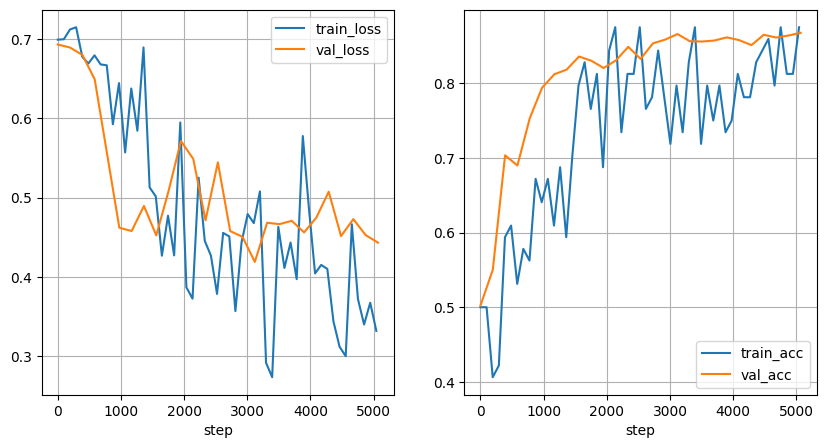

In [203]:
# 注意：训练损失不会单调下降到 0，因为 sigmoid(logit) 不会精确等于 0 或 1
def plot_learning_curves(record_dict, sample_step=500):
    """
    绘制训练/验证集的损失和准确率曲线
    参数：
        record_dict (dict): training() 返回的历史记录字典
        sample_step (int):  训练曲线下采样步长，避免点过多导致绘图慢
    """
    # 构建 DataFrame，按 step 设置索引；每 sample_step 取一个训练集点
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df   = pd.DataFrame(record_dict["val"]).set_index("step")  # 验证集全部绘制

    fig_num = len(train_df.columns)  # 子图数 = 指标数（loss + acc）
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))  # 横排排列

    for idx, item in enumerate(train_df.columns):
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")  # 训练曲线
        axs[idx].plot(val_df.index,   val_df[item],   label=f"val_{item}")    # 验证曲线
        axs[idx].grid()           # 显示网格
        axs[idx].legend()         # 显示图例
        axs[idx].set_xlabel("step")  # x 轴标签

    plt.show()

sample_step=eval_step//2
plot_learning_curves(record, sample_step)  


## 八、推理与评估

In [200]:
# 加载训练时保存的最优权重，用于最终推理评估

# torch.load 读取检查点文件；weights_only=True 更安全（只加载权重，不执行代码）
# map_location='cpu' 确保无 GPU 时也能正常加载
model.load_state_dict(
    torch.load("model_checkpoints/1_model/1_model_best.ckpt",
               weights_only=True, map_location="cpu")
)

# 在测试集上计算最终损失和准确率
loss, acc = evaluating(model, test_dl, loss_fct)

# 格式化输出评估结果（保留 4 位小数）
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")


loss:     0.4431
accuracy: 0.8675
